In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
stocks = ["AAPL", "TSLA"]
data = yf.download(stocks, start="2019-01-01", end="2024-02-22")
data.to_csv("stock_data.csv")


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


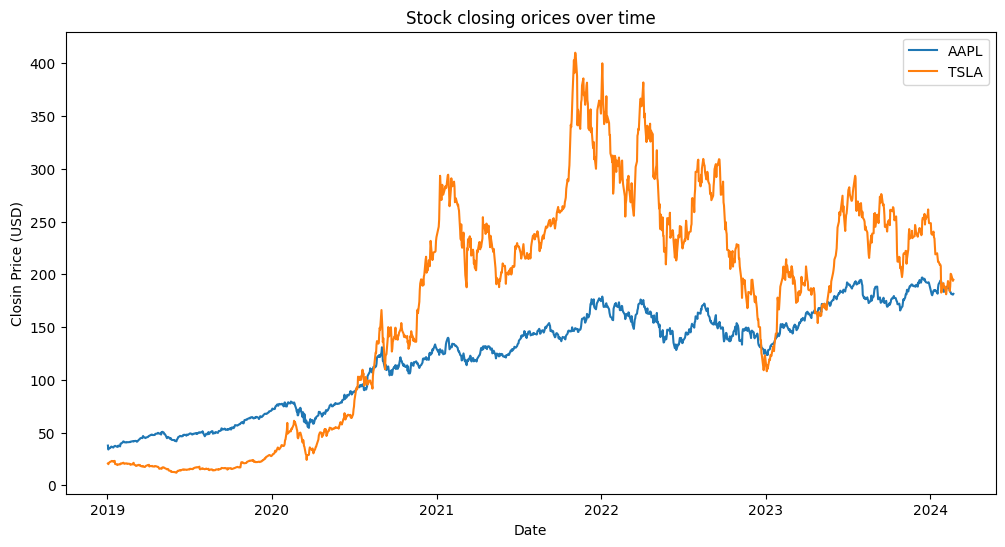

In [ ]:
plt.figure(figsize=(12,6))
for stock in stocks:
    plt.plot(data['Close'][stock], label=stock)

plt.title("Stock closing orices over time")
plt.xlabel("Date")
plt.ylabel("Closin Price (USD)")
plt.legend()
plt.show()

In [5]:
#checking for missing values
print(data['Close'].isnull().sum())
data['Close'].fillna(method='ffill', inplace = True)
print(data['Close'].isnull().sum())

Ticker
AAPL    0
TSLA    0
dtype: int64
Ticker
AAPL    0
TSLA    0
dtype: int64


C:\Users\anagh\AppData\Local\Temp\ipykernel_2840\4189901423.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Close'].fillna(method='ffill', inplace = True)
C:\Users\anagh\AppData\Local\Temp\ipykernel_2840\4189901423.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Close'].fillna(method='ffill', inplace = True)


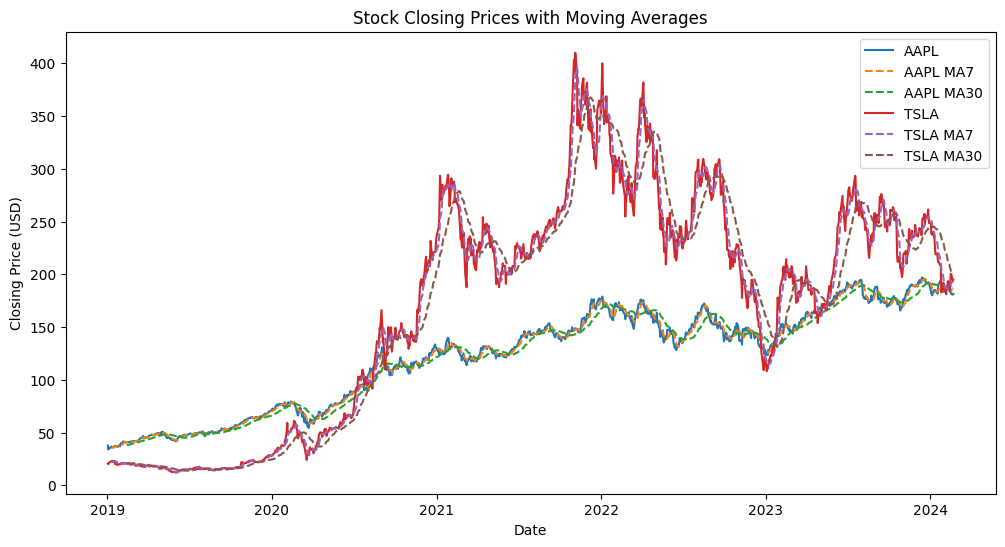

In [6]:
#Feature Engineering
# Calculate 7-day and 30-day moving averages for both stocks
data['AAPL_MA7'] = data['Close']['AAPL'].rolling(window=7).mean()
data['AAPL_MA30'] = data['Close']['AAPL'].rolling(window=30).mean()

data['TSLA_MA7'] = data['Close']['TSLA'].rolling(window=7).mean()
data['TSLA_MA30'] = data['Close']['TSLA'].rolling(window=30).mean()

# Plot moving averages
plt.figure(figsize=(12,6))
for stock in stocks:
    plt.plot(data['Close'][stock], label=stock)
    plt.plot(data[f'{stock}_MA7'], label=f'{stock} MA7', linestyle='--')
    plt.plot(data[f'{stock}_MA30'], label=f'{stock} MA30', linestyle='--')

plt.title("Stock Closing Prices with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.show()


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
columns_to_scale = ['Close', 'AAPL_MA7', 'AAPL_MA30', 'TSLA_MA7', 'TSLA_MA30']
data_scaled = data[columns_to_scale].copy()

data_scaled = scaler.fit_transform(data_scaled)

# Adjust column names to reflect both stocks
columns_to_scale = ['AAPL_Close', 'AAPL_MA7', 'AAPL_MA30', 'TSLA_Close', 'TSLA_MA7', 'TSLA_MA30']

In [16]:
print(data_scaled.shape)


(1293, 6)


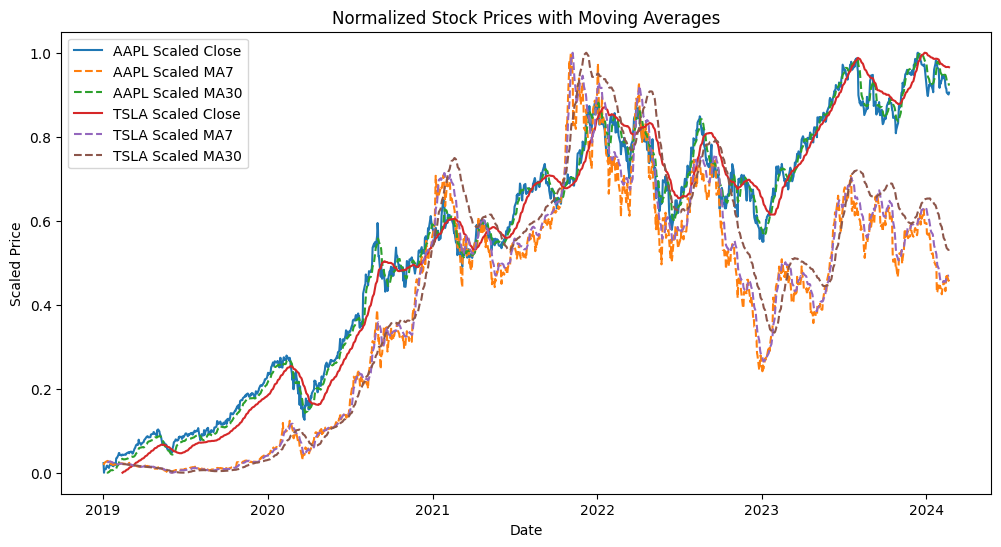

In [17]:
data_scaled = pd.DataFrame(data_scaled, columns=columns_to_scale, index=data.index)

# Plot the normalized data with moving averages
plt.figure(figsize=(12,6))
for stock in stocks:
    plt.plot(data_scaled[f'{stock}_Close'], label=f'{stock} Scaled Close')
    plt.plot(data_scaled[f'{stock}_MA7'], label=f'{stock} Scaled MA7', linestyle='--')
    plt.plot(data_scaled[f'{stock}_MA30'], label=f'{stock} Scaled MA30', linestyle='--')

plt.title("Normalized Stock Prices with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Scaled Price")
plt.legend()
plt.show()

In [18]:
# Creating lag features (e.g., previous day's closing price)
data_scaled['AAPL_Close_Lag1'] = data_scaled['AAPL_Close'].shift(1)
data_scaled['TSLA_Close_Lag1'] = data_scaled['TSLA_Close'].shift(1)

# Creating lag features for moving averages
data_scaled['AAPL_MA7_Lag1'] = data_scaled['AAPL_MA7'].shift(1)
data_scaled['TSLA_MA7_Lag1'] = data_scaled['TSLA_MA7'].shift(1)

# Drop any NaN values caused by shifting
data_scaled = data_scaled.dropna()


In [20]:
# For AAPL prediction
X_aapl = data_scaled.drop(columns=['AAPL_Close'])
y_aapl = data_scaled['AAPL_Close']

# For TSLA prediction
X_tsla = data_scaled.drop(columns=['TSLA_Close'])
y_tsla = data_scaled['TSLA_Close']

# Split data into training and testing sets (80% train, 20% test) for both stocks
from sklearn.model_selection import train_test_split
X_aapl_train, X_aapl_test, y_aapl_train, y_aapl_test = train_test_split(X_aapl, y_aapl, test_size=0.2, shuffle=False)
X_tsla_train, X_tsla_test, y_tsla_train, y_tsla_test = train_test_split(X_tsla, y_tsla, test_size=0.2, shuffle=False)


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Initialize Linear Regression model
model_aapl = RandomForestRegressor(n_estimators=100, random_state=42)
model_tsla = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the models for both stocks
model_aapl.fit(X_aapl_train, y_aapl_train)
model_tsla.fit(X_tsla_train, y_tsla_train)

# Make predictions for both stocks
y_aapl_pred = model_aapl.predict(X_aapl_test)
y_tsla_pred = model_tsla.predict(X_tsla_test)

# Evaluate the models using Mean Squared Error
mse_aapl = mean_squared_error(y_aapl_test, y_aapl_pred)
mse_tsla = mean_squared_error(y_tsla_test, y_tsla_pred)

print(f'AAPL Mean Squared Error: {mse_aapl}')
print(f'TSLA Mean Squared Error: {mse_tsla}')


AAPL Mean Squared Error: 0.00641408663181588
TSLA Mean Squared Error: 0.004651548027185139


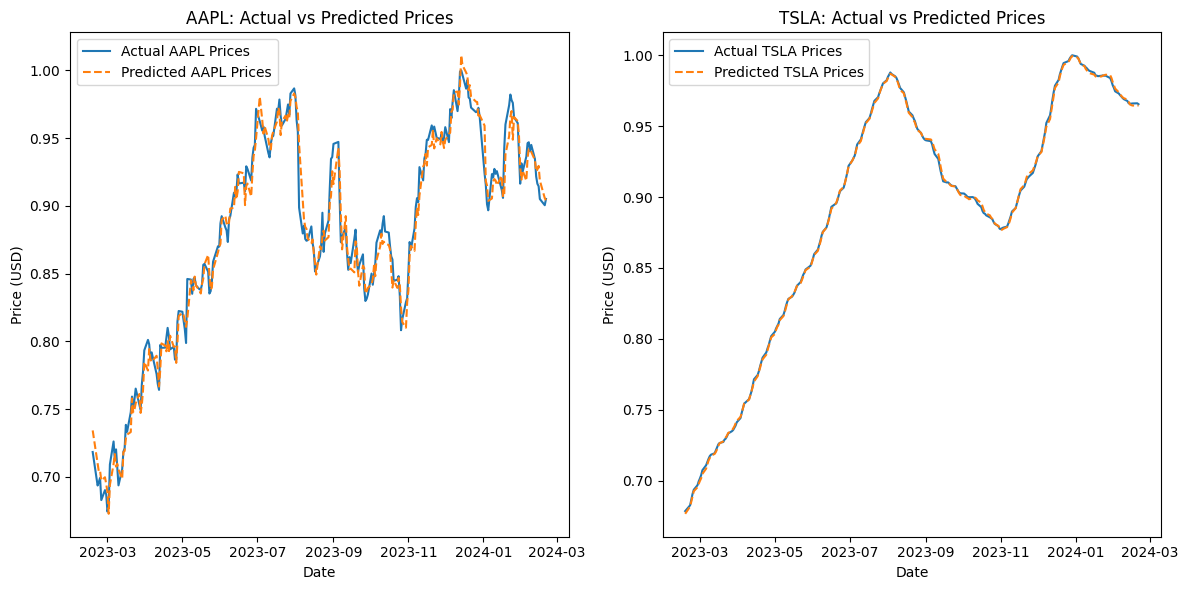

In [22]:
# Plot actual vs predicted prices for both AAPL and TSLA
plt.figure(figsize=(12,6))

# Plot for AAPL
plt.subplot(1, 2, 1)
plt.plot(y_aapl_test.index, y_aapl_test, label='Actual AAPL Prices')
plt.plot(y_aapl_test.index, y_aapl_pred, label='Predicted AAPL Prices', linestyle='--')
plt.title("AAPL: Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

# Plot for TSLA
plt.subplot(1, 2, 2)
plt.plot(y_tsla_test.index, y_tsla_test, label='Actual TSLA Prices')
plt.plot(y_tsla_test.index, y_tsla_pred, label='Predicted TSLA Prices', linestyle='--')
plt.title("TSLA: Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.tight_layout()
plt.show()
